In [1]:
!pip install kagglehub


In [2]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.9 MB/s eta 0:00:00


#Download Datasets

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahwagih/kvasir-dataset-for-classification-and-segmentation")

print("Path to dataset files:", path)

100%|██████████| 1.20G/1.20G [01:00<00:00, 21.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdallahwagih/kvasir-dataset-for-classification-and-segmentation/versions/1


In [4]:
mv /root/.cache/kagglehub/datasets/abdallahwagih/kvasir-dataset-for-classification-and-segmentation/versions/1 .

# Importing some essential Libraries


In [5]:
import os
import cv2
import numpy as np
from glob import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt


In [6]:
image_dir = "/content/1/kvasir-seg/Kvasir-SEG/images"
mask_dir = "/content/1/kvasir-seg/Kvasir-SEG/masks"
batch_size = 64
device = 'cuda' if torch.cuda.is_available else 'cpu'

In [7]:
class SegmenatationDataset(Dataset):
  def __init__(self, img_paths:list, mask_paths:list, transform=None):
    self.img_paths = img_paths
    self.mask_paths = mask_paths
    self.transform = transform

  def __len__(self):
    return len(self.img_paths)

  def __getitem__(self, index):
    image= cv2.imread(self.img_paths[index])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (256, 256))
    image = image.astype('float32') / 255.0

    mask = cv2.imread(self.mask_paths[index], cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256))
    mask = mask.astype('float32') / 255.0
    mask = np.expand_dims(mask, axis=0) # (1, 256, 256)

    image = torch.tensor(image).permute(2, 0, 1)
    mask = torch.tensor(mask)

    return image, mask

image_paths = sorted(glob(os.path.join(image_dir,"*jpg")))
mask_paths = sorted(glob(os.path.join(mask_dir,"*jpg")))


train_images, val_image, train_mask, val_mask = train_test_split(image_paths,
                                                                 mask_paths,
                                                                 test_size=0.2,
                                                                 random_state=42)

train_dataset = SegmenatationDataset(train_images, train_mask)
val_dataset = SegmenatationDataset(val_image, val_mask)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [8]:
img, mask = train_dataset[0]

In [9]:
img.size(), mask.size()

(torch.Size([3, 256, 256]), torch.Size([1, 256, 256]))

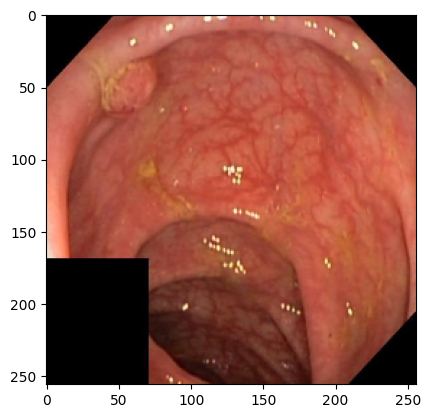

In [10]:
plt.imshow(img.permute(1,2,0))

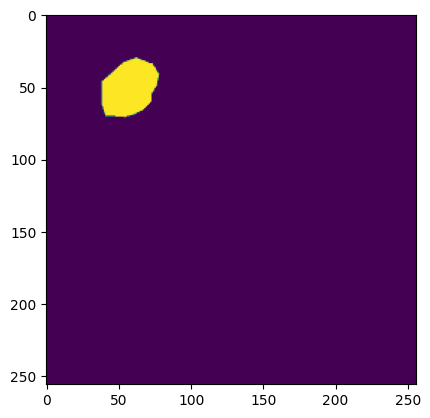

In [11]:
plt.imshow(mask.permute(1,2,0))

#Model

In [12]:
model=smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1)
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

# Training Pipeline

In [13]:
best_loss = float("inf")
epochs = 10

for epoch in range(epochs):
  model.train()
  train_loss = 0.0

  for images, mask in train_loader:
    images, mask = images.to(device), mask.to(device)

    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, mask)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
  model.eval()
  val_loss = 0.0
  with torch.no_grad():
    for images, mask in val_loader:
      images, mask = images.to(device), mask.to(device)
      output =model(images)
      loss = criterion(output, mask)
      val_loss += loss.item()

  train_loss = train_loss/len(train_loader)
  val_loss =val_loss/len(val_loader)

  print(f"Epoch: {epoch}/{epochs}, Train Loss: {train_loss}, Val Loss: {val_loss}")

  if val_loss < best_loss:
    best_loss = val_loss
    torch.save(model.state_dict(), "best_model.pth")
    print(f"saving best model with val_loss {val_loss} at best_model.pth")

Epoch: 0/10, Train Loss: 0.43793501532994783, Val Loss: 21.21985912322998
saving best model with val_loss 21.21985912322998 at best_model.pth
Epoch: 1/10, Train Loss: 0.22832055848378402, Val Loss: 0.276514396071434
saving best model with val_loss 0.276514396071434 at best_model.pth
Epoch: 2/10, Train Loss: 0.15397993647135222, Val Loss: 0.18921563029289246
saving best model with val_loss 0.18921563029289246 at best_model.pth
Epoch: 3/10, Train Loss: 0.11444626576625384, Val Loss: 0.16716871410608292
saving best model with val_loss 0.16716871410608292 at best_model.pth
Epoch: 4/10, Train Loss: 0.09998463208858784, Val Loss: 0.17154628038406372
Epoch: 5/10, Train Loss: 0.09557464374945714, Val Loss: 0.16291538253426552
saving best model with val_loss 0.16291538253426552 at best_model.pth
Epoch: 6/10, Train Loss: 0.08337278492175616, Val Loss: 0.17713240161538124
Epoch: 7/10, Train Loss: 0.06318852907189956, Val Loss: 0.13514163717627525
saving best model with val_loss 0.1351416371762752

# Inference

In [15]:
def infer_and_visualize(model, image_path, device):
  image= cv2.imread(image_path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  image = cv2.resize(image, (256, 256))
  image = image.astype('float32') / 255.0  #(256, 256, 3)

  image_tensor = torch.tensor(image).permute(2,0,1).unsqueeze(0).to(device) # (1,3,256,256)

  with torch.no_grad():
    output = model(image_tensor)
    output = torch.sigmoid(output).cpu().squeeze().numpy()
    output = (output > 0.5).astype(np.uint8)

  plt.figure(figsize=(10,5))
  plt.subplot(1,3,1)
  plt.title("Original Image")
  plt.imshow(image)

  plt.subplot(1,3,2)
  plt.title("Mask Image")
  plt.imshow(output)

  plt.subplot(1,3,3)
  plt.title("Overlap Image")
  plt.imshow(image)
  plt.imshow(output, cmap='jet', alpha=0.5)

  plt.show()


In [16]:
model.load_state_dict(torch.load("/content/best_model.pth"))

<All keys matched successfully>

In [20]:
sample_image = "/content/1/kvasir-seg/Kvasir-SEG/images/cju15czxqp3lv0835jvhgzurz.jpg"


In [21]:
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

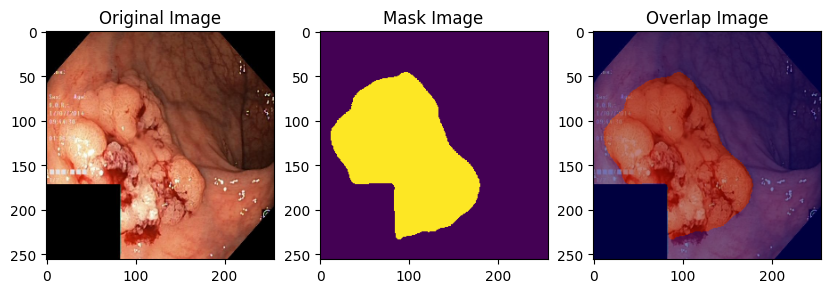

In [22]:
infer_and_visualize(model, sample_image, device)

In [23]:
sample_image1 = "/content/1/kvasir-seg/Kvasir-SEG/images/cju14pxbaoksp0835qzorx6g6.jpg"

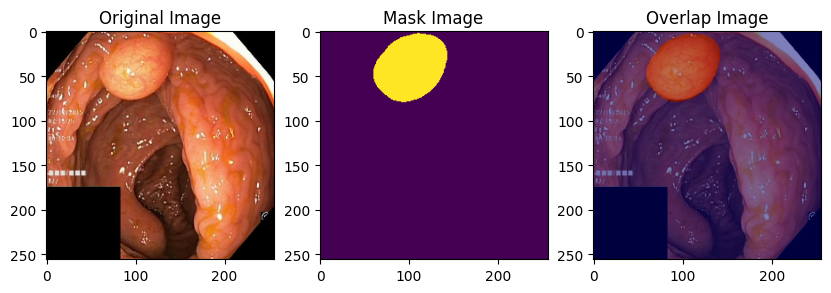

In [24]:
infer_and_visualize(model, sample_image1, device)